In [77]:
# Olaf Surgut, 345615

import torch as T
import torchvision as TV
import matplotlib.pyplot as plt

SEED=42
T.manual_seed(SEED)
device = T.device("cuda") if T.cuda.is_available() else T.device("cpu")

In [78]:
data_train = TV.datasets.FashionMNIST('./data', train=True, download=True)
data_valid = TV.datasets.FashionMNIST('./data', train=False, download=True)

class_names = data_train.classes
target_name = 'Shirt'
target_idx = class_names.index(target_name)

In [79]:
def prepare_dataset(dataset, target_idx):
    images = dataset.data.float()
    labels = dataset.targets.clone()

    positive_mask = labels == target_idx
    negative_mask = labels != target_idx
    
    positive_images = images[positive_mask]
    positive_labels = T.ones((positive_images.shape[0], 1), dtype=T.float32)
        
    negative_images = images[negative_mask]
    negative_labels = T.zeros((negative_images.shape[0], 1), dtype=T.float32)

    positive_count  = positive_images.shape[0]
    perm = T.randperm(negative_images.shape[0])
    
    negative_images = negative_images[perm[:positive_count]]
    negative_labels = negative_labels[perm[:positive_count]]
    
    X = T.cat([positive_images, negative_images])
    y = T.cat([positive_labels, negative_labels])

    perm = T.randperm(X.shape[0])
    X = X[perm]
    y = y[perm]

    X = X.view(X.shape[0], -1).to(device)
    y = y.view(y.shape[0], -1).to(device)

    return X, y

X_train, y_train = prepare_dataset(data_train, target_idx)
X_valid, y_valid = prepare_dataset(data_valid, target_idx)

print(X_train.shape, y_train.shape)
print((y_train == 1).sum(), (y_train == 0).sum())

torch.Size([12000, 784]) torch.Size([12000, 1])
tensor(6000, device='cuda:0') tensor(6000, device='cuda:0')


### Which class you chose as positive?
> Shirts
### The number of positive and negative samples
> 6000 positive and negative samples each
### The shapes of the resulting tensor
> [12000, 784] for features and [12000, 1] for targets

# Task 1

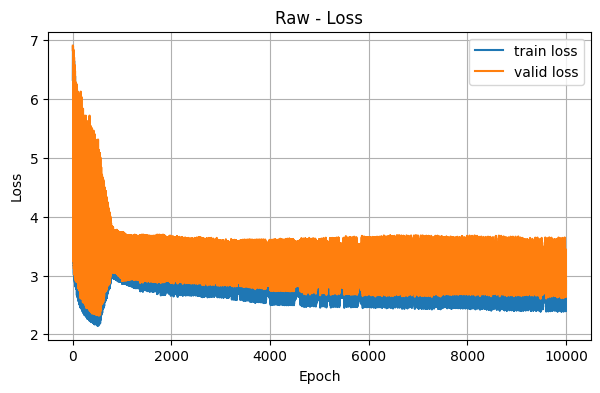

Final train loss: 2.902076244354248
Final valid loss: 2.705565929412842


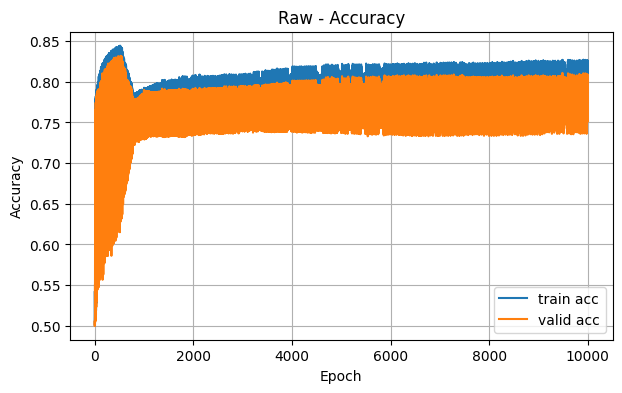

Final train acc: 0.7895833253860474
Final valid acc: 0.8040000200271606


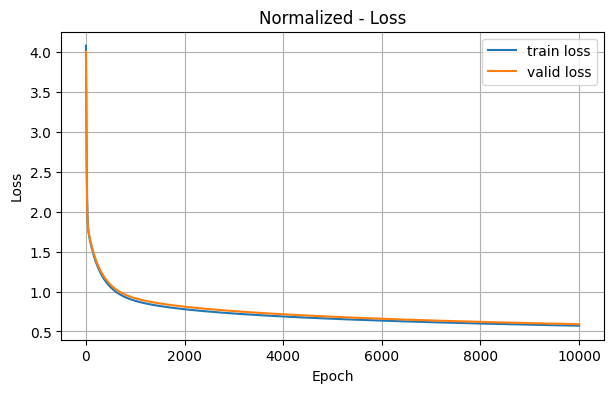

Final train loss: 0.5718435049057007
Final valid loss: 0.5908562541007996


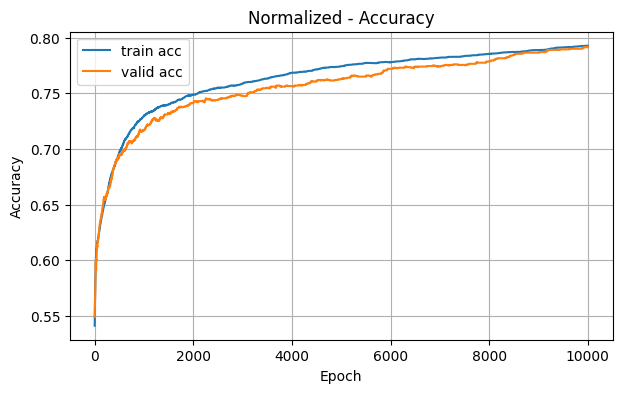

Final train acc: 0.7927500009536743
Final valid acc: 0.7915000319480896


In [82]:
X_train_raw = X_train
X_valid_raw = X_valid

X_train_nor = X_train / 255.0
X_valid_nor = X_valid / 255.0

def sigmoid(z):
    return 1 / (1 + T.exp(-z))

def binary_cross_entropy(y_hat, y, eps=1e-6):
    y_hat = T.clamp(y_hat, eps, 1 - eps)
    return -T.mean(y * T.log(y_hat) + (1 - y) * T.log(1 - y_hat))

def logistic_forward(X, W, b):
    z = X @ W + b
    y_hat = sigmoid(z)
    return z, y_hat

def logistic_gradients(X, y_hat, y):
    N = X.shape[0]
    dz = y_hat - y
    dW = (X.T @ dz) / N
    db = dz.mean(dim=0, keepdim=True)
    return dW, db.squeeze()

def accuracy(y_hat, y):
    preds = (y_hat >= 0.5).float()
    return (preds == y).float().mean().item()

def train_logistic(X_train, y_train, X_valid, y_valid, lr=1e-2, epochs=10000):
    T.manual_seed(SEED)

    d = X_train.shape[1]
    W = T.randn(d, 1, device=device)
    b = T.zeros(1, device=device)

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }
    
    for epoch in range(epochs):
        _, y_hat_train = logistic_forward(X_train, W, b)
        train_loss = binary_cross_entropy(y_hat_train, y_train)
        train_acc  = accuracy(y_hat_train, y_train)
        
        dW, db = logistic_gradients(X_train, y_hat_train, y_train)
        
        W = W - lr * dW
        b = b - lr * db

        _, y_hat_valid = logistic_forward(X_valid, W, b)
        valid_loss = binary_cross_entropy(y_hat_valid, y_valid)
        valid_acc  = accuracy(y_hat_valid, y_valid)

        history["train_loss"].append(train_loss.item())
        history["valid_loss"].append(valid_loss.item())
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)
    
    return W, b, history

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["valid_loss"], label="valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final train loss: {history['train_loss'][-1]}")
    print(f"Final valid loss: {history['valid_loss'][-1]}")
    
    plt.figure(figsize=(7,4))
    plt.plot(epochs, history["train_acc"], label="train acc")
    plt.plot(epochs, history["valid_acc"], label="valid acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final train acc: {history['train_acc'][-1]}")
    print(f"Final valid acc: {history['valid_acc'][-1]}")


W_raw, b_raw, hist_raw = train_logistic(
    X_train_raw, y_train, X_valid_raw, y_valid
)

plot_history(hist_raw, "Raw")

W_nor, b_nor, hist_nor = train_logistic(
    X_train_nor, y_train, X_valid_nor, y_valid
)

plot_history(hist_nor, "Normalized")



        

### Why logistic regression is suitable for binary classification?
Logistic regression produces a single value in the range [0, 1], which can be interpreted as the probability.
### Why sigmoid is used?
It maps arbitrary values to probabilities between 0 and 1
### Why the derivative simplifies to $\frac{\partial L}{\partial z} = \hat{y} - y$?
$$\hat{y} = \frac{1}{1+\exp{-z}}$$
$$L(\hat{y}, y) = -[y \log \hat{y} + (1-y)\log(1-\hat{y})]$$
Using chain rule
$$\frac{\partial L}{\partial z} = \frac{\partial{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} $$
$$ \frac{\partial L}{\partial \hat{y}} = -(y \cdot \frac{1}{\hat{y}} + (1-y)\cdot \frac{-1}{ 1-\hat{y}}) = -\frac{y}{\hat{y}}+\frac{1-y}{1-\hat{y}}$$
$$ \frac{\partial \hat{y}}{\partial z} = \hat{y}(1-\hat{y})$$

$$ \frac{\partial L}{\partial z} = (-\frac{y}{\hat{y}}+\frac{1-y}{1-\hat{y}})\hat{y}(1-\hat{y}) = \hat{y} - y$$
### Why we can implement gradient descent here without autograd?
The gradient descent method is in a really nice, compact form.

# Task 2

In [90]:
BATCH_SIZE = 64
X_batch = X_train_nor[:BATCH_SIZE].clone()
y_batch = y_train[:BATCH_SIZE].clone()

W = W_nor.clone()
b = b_nor.clone()

z = X_batch @ W + b
y_hat = sigmoid(z)
loss = binary_cross_entropy(y_hat, y_batch)
dW, db = logistic_gradients(X_batch, y_hat, y_batch)

W_auto = W_nor.clone().requires_grad_(True)
b_auto = b_nor.clone().requires_grad_(True)

z_auto = X_batch @ W_auto + b_auto
y_hat_auto = sigmoid(z_auto)
loss_auto = binary_cross_entropy(y_hat_auto, y_batch)
loss_auto.backward()

dW_auto = W_auto.grad.clone()
db_auto = b_auto.grad.clone()

W_diff = T.norm(dW - dW_auto).item()
b_diff = T.norm(db - db_auto).item()

print(f"Manual loss:   {loss.item()}")
print(f"Autograd loss: {loss_auto.item()}")
print(f"||dW_manual - dW_auto|| = {W_diff}")
print(f"||db_manual - db_auto|| = {b_diff}")

Manual loss:   0.8520764112472534
Autograd loss: 0.8520764112472534
||dW_manual - dW_auto|| = 5.39070060767699e-06
||db_manual - db_auto|| = 3.0547380447387695e-07


### Why the two gradients should match?
Both compute the derivatives of the same loss function
### Possible reasons for small numerical differences
Floating-point precision, different internal evaluation order, rounding errors
### Why checking gradietns is useful when implementing models from scratch?
Helps verify that the forward pass and gradient formulas are correct. Big mismatch suggest a big in formulas or in the model.

# Task 3

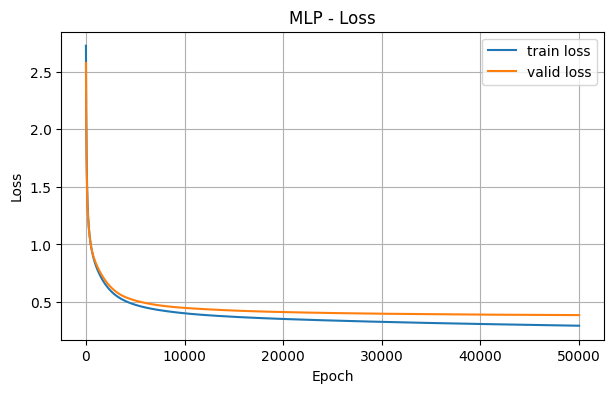

Final train loss: 0.2941856384277344
Final valid loss: 0.38640928268432617


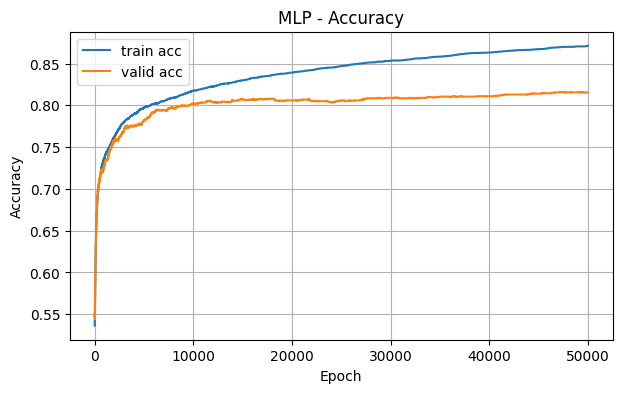

Final train acc: 0.8714166283607483
Final valid acc: 0.815500020980835


In [102]:
def mlp1_forward(X, params):
    W1, b1, W2, b2 = params
    z1 = X @ W1 + b1
    a1 = T.tanh(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat

def train_mlp1(X_train, y_train, X_valid, y_valid, hidden_dim=128, lr=0.01, epochs=50000):
    T.manual_seed(SEED)

    input_dim = X_train.shape[1]

    W1 = T.randn(input_dim, hidden_dim, device=device, requires_grad=True)
    b1 = T.zeros(hidden_dim, device=device, requires_grad=True)
    W2 = T.randn(hidden_dim, 1, device=device, requires_grad=True)
    b2 = T.zeros(1, device=device, requires_grad=True)

    params = [W1, b1, W2, b2]

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }

    for epoch in range(epochs):
        y_hat_train = mlp1_forward(X_train, params)
        train_loss = binary_cross_entropy(y_hat_train, y_train)
        train_acc = accuracy(y_hat_train, y_train)

        train_loss.backward()
        with T.no_grad():
            for p in params:
                p -= lr * p.grad

        for p in params:
            p.grad.zero_()

        with T.no_grad():
            y_hat_valid = mlp1_forward(X_valid, params)
            valid_loss = binary_cross_entropy(y_hat_valid, y_valid)
            valid_acc = accuracy(y_hat_valid, y_valid)

        history["train_loss"].append(train_loss.item())
        history["valid_loss"].append(valid_loss.item())
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)

    return params, history

params_mlp1, hist_mlp1 = train_mlp1(
    X_train_nor, y_train,
    X_valid_nor, y_valid
)

plot_history(hist_mlp1, "MLP")

### Why an MLP can model more complex decisions bounddaries than logistic regression?
It includes hidden layer and a nonlinear activation function inside. Logistic can only learn linear bondary in the input space.
### The role of the hidden activation function
Introduces nonlinearity, which allows the network to learn more complex patterns.
### Why we still need a sigmoid in the output layer
This is still a binary classification problem, the output of the model must represent a probability between 0 and 1.

# Task 4

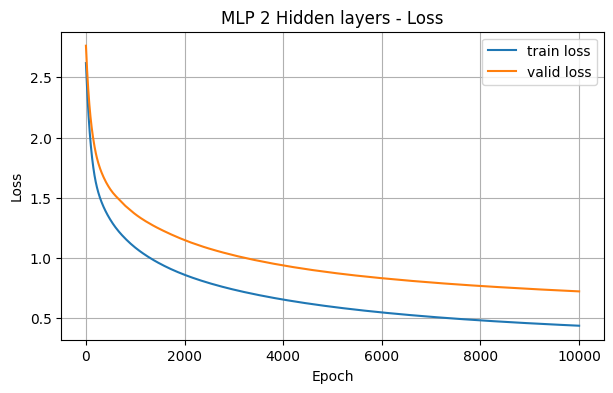

Final train loss: 0.43664607405662537
Final valid loss: 0.7218221426010132


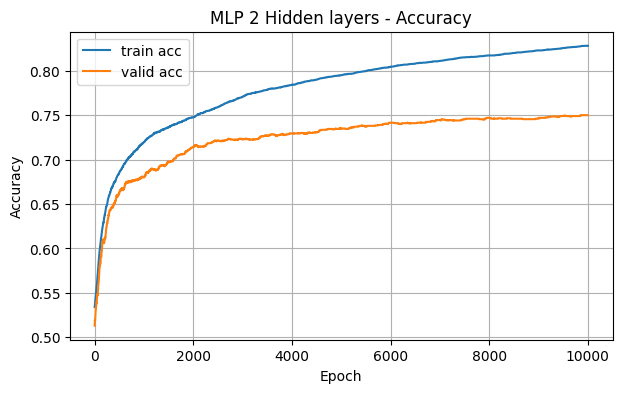

Final train acc: 0.828083336353302
Final valid acc: 0.7500000596046448


In [104]:
def mlp2_forward(X, params):
    W1, b1, W2, b2, W3, b3 = params
    z1 = X @ W1 + b1
    a1 = T.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = T.tanh(z2)
    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)
    return y_hat

def train_mlp2(X_train, y_train, X_valid, y_valid, hidden1_dim=128, hidden2_dim=128, lr=0.005, epochs=10000):
    T.manual_seed(SEED)

    input_dim = X_train.shape[1]

    W1 = T.randn(input_dim, hidden1_dim, device=device, requires_grad=True)
    b1 = T.zeros(hidden1_dim, device=device, requires_grad=True)
    W2 = T.randn(hidden1_dim, hidden2_dim, device=device, requires_grad=True)
    b2 = T.zeros(hidden2_dim, device=device, requires_grad=True)
    W3 = T.randn(hidden2_dim, 1, device=device, requires_grad=True)
    b3 = T.zeros(1, device=device, requires_grad=True)

    params = [W1, b1, W2, b2, W3, b3]

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }

    for epoch in range(epochs):
        y_hat_train = mlp2_forward(X_train, params)
        train_loss = binary_cross_entropy(y_hat_train, y_train)
        train_acc = accuracy(y_hat_train, y_train)

        train_loss.backward()
        with T.no_grad():
            for p in params:
                p -= lr * p.grad

        for p in params:
            p.grad.zero_()

        with T.no_grad():
            y_hat_valid = mlp2_forward(X_valid, params)
            valid_loss = binary_cross_entropy(y_hat_valid, y_valid)
            valid_acc = accuracy(y_hat_valid, y_valid)

        history["train_loss"].append(train_loss.item())
        history["valid_loss"].append(valid_loss.item())
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)

    return params, history

params_mlp2, hist_mlp2 = train_mlp2(
    X_train_nor, y_train,
    X_valid_nor, y_valid
)

plot_history(hist_mlp2, "MLP 2 Hidden layers")

### Discuss whether deeper models improve performance
No, the accuracy and the loss got worse for the validation.
That means the model memorized instead of generalized.
### Whether the extra hidden layer was helpful
More layers means more parameters. Model can potentialy learn more abstract intermediate representations.
### Why a deeper model may help or may fail to help on this binary task
Whether the second hiddenl ayer is useful should be judged by the final validation loss and accuracy. In this case it failed miserably, some other tricks needs to be incorporated.

In [ ]:
g